In [3]:
install.packages("bnlearn")
library(bnlearn)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# VERİ

In [6]:
if (!requireNamespace("bnlearn", quietly = TRUE)) {
  install.packages("bnlearn")
}
library(bnlearn)

cat("\n--- VERİ ---\n")

autism <- read.csv("autism.csv", stringsAsFactors = TRUE, fileEncoding = "UTF-8")

print(head(autism))
str(autism)

cat("\n--- VERİ KONTROLÜ ---\n")

cat("Gözlem sayısı :", nrow(autism), "\n")
cat("Değişken sayısı:", ncol(autism), "\n")

eksik <- sum(is.na(autism))
cat("Eksik değer sayısı:", eksik, "\n")
if (eksik > 0) {
  cat("UYARI: Eksik değerler bulundu — na.omit() ile temizleniyor\n")
  autism <- na.omit(autism)
}

hepsi_faktor <- all(sapply(autism, is.factor))
cat("Tüm değişkenler faktör mü?", hepsi_faktor, "\n")
if (!hepsi_faktor) {
  cat("UYARI: Faktör olmayanlar dönüştürülüyor\n")
  autism[] <- lapply(autism, as.factor)
}

cat("\nDeğişken düzeyleri:\n")
for (col in colnames(autism)) {
  cat(sprintf("  %-16s: %s\n", col, paste(levels(autism[[col]]), collapse=" / ")))
}

learning.test <- autism

cat("\nVeri kontrolü tamamlandı. Devam ediliyor...\n")


--- VERİ ---
  Duyusal.Profil Dil.Duzeyi Sosyal.Katilim Yogunluk Aile.Destegi Genelleme
1           hipo non-verbal          dusuk >=20saat       yuksek       neg
2          hiper     verbal         yuksek >=20saat       yuksek       pos
3           hipo non-verbal          dusuk >=20saat       yuksek       pos
4           hipo     verbal         yuksek  <20saat       yuksek       pos
5          hiper non-verbal         yuksek  <20saat       yuksek       pos
6           hipo     verbal          dusuk  <20saat        dusuk       neg
'data.frame':	1841 obs. of  6 variables:
 $ Duyusal.Profil: Factor w/ 2 levels "hiper","hipo": 2 1 2 2 1 2 2 2 1 1 ...
 $ Dil.Duzeyi    : Factor w/ 2 levels "non-verbal","verbal": 1 2 1 2 1 2 1 2 1 2 ...
 $ Sosyal.Katilim: Factor w/ 2 levels "dusuk","yuksek": 1 2 1 2 2 1 1 2 1 2 ...
 $ Yogunluk      : Factor w/ 2 levels "<20saat",">=20saat": 2 2 2 1 1 1 2 1 2 1 ...
 $ Aile.Destegi  : Factor w/ 2 levels "dusuk","yuksek": 2 2 2 2 2 1 1 2 2 1 ...
 $ Genelleme 

# MODEL


--- MODEL ---

Nedensel Katmanlar:
[[1]]
[1] "Duyusal.Profil" "Dil.Duzeyi"     "Aile.Destegi"  

[[2]]
[1] "Sosyal.Katilim" "Yogunluk"      

[[3]]
[1] "Genelleme"


Whitelist (Zorunlu Kenarlar):
            from        to
1   Aile.Destegi  Yogunluk
2 Sosyal.Katilim Genelleme
3       Yogunluk Genelleme

Blacklist (Yasaklı Kenarlar — katman ihlalleri):
      from             to              
 [1,] "Sosyal.Katilim" "Duyusal.Profil"
 [2,] "Yogunluk"       "Duyusal.Profil"
 [3,] "Genelleme"      "Duyusal.Profil"
 [4,] "Sosyal.Katilim" "Dil.Duzeyi"    
 [5,] "Yogunluk"       "Dil.Duzeyi"    
 [6,] "Genelleme"      "Dil.Duzeyi"    
 [7,] "Sosyal.Katilim" "Aile.Destegi"  
 [8,] "Yogunluk"       "Aile.Destegi"  
 [9,] "Genelleme"      "Aile.Destegi"  
[10,] "Genelleme"      "Sosyal.Katilim"
[11,] "Genelleme"      "Yogunluk"      

  Bayesian network learned via Hybrid methods

  model:
   [Duyusal.Profil][Dil.Duzeyi][Aile.Destegi]
   [Sosyal.Katilim|Duyusal.Profil:Dil.Duzeyi][Yogunluk|Aile.De

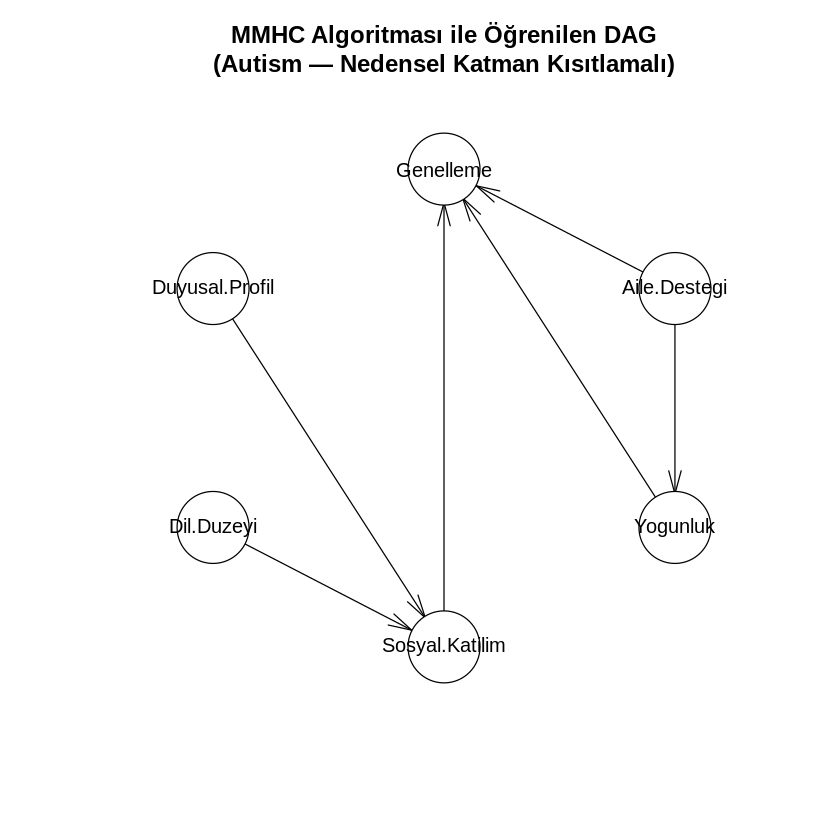

In [7]:
cat("\n--- MODEL ---\n")

katmanlar <- list(
  c("Duyusal.Profil", "Dil.Duzeyi", "Aile.Destegi"),
  c("Sosyal.Katilim", "Yogunluk"),
  c("Genelleme")
)

bl <- tiers2blacklist(katmanlar)

wl <- data.frame(
  from = c("Aile.Destegi", "Sosyal.Katilim", "Yogunluk"),
  to   = c("Yogunluk",     "Genelleme",      "Genelleme")
)

cat("\nNedensel Katmanlar:\n")
print(katmanlar)
cat("\nWhitelist (Zorunlu Kenarlar):\n")
print(wl)
cat("\nBlacklist (Yasaklı Kenarlar — katman ihlalleri):\n")
print(bl)

dag_model <- mmhc(learning.test, whitelist = wl, blacklist = bl)

print(dag_model)

cat("\nÖğrenilen Modelin Kenarları (Arcs):\n")
print(arcs(dag_model))

plot(dag_model, main = "MMHC Algoritması ile Öğrenilen DAG\n(Autism — Nedensel Katman Kısıtlamalı)")

# DEĞERLENDİRME


--- DEĞERLENDİRME ---

Bootstrap Sonuçları (İlk 6 satır):
            from             to strength direction
1 Duyusal.Profil     Dil.Duzeyi    0.008       0.5
2 Duyusal.Profil Sosyal.Katilim    1.000       1.0
3 Duyusal.Profil       Yogunluk    0.020       1.0
4 Duyusal.Profil   Aile.Destegi    0.002       0.5
5 Duyusal.Profil      Genelleme    0.000       0.0
6     Dil.Duzeyi Duyusal.Profil    0.008       0.5

Oldukça Güvenilir Kenarlar (Strength > 0.85):
             from             to strength direction
2  Duyusal.Profil Sosyal.Katilim    1.000         1
7      Dil.Duzeyi Sosyal.Katilim    1.000         1
15 Sosyal.Katilim      Genelleme    1.000         1
20       Yogunluk      Genelleme    1.000         1
24   Aile.Destegi       Yogunluk    1.000         1
25   Aile.Destegi      Genelleme    0.994         1

Sınırdaki Kenarlar (Strength 0.50 - 0.85):
[1] from      to        strength  direction
<0 rows> (or 0-length row.names)

--- WHITELIST TUTARLILIK KONTROLÜ ---
Whitelist ken

agg_record_bf93dda5c6e 
                     2

dag_gorsel.png kaydedildi

Pipeline tamamlandı.


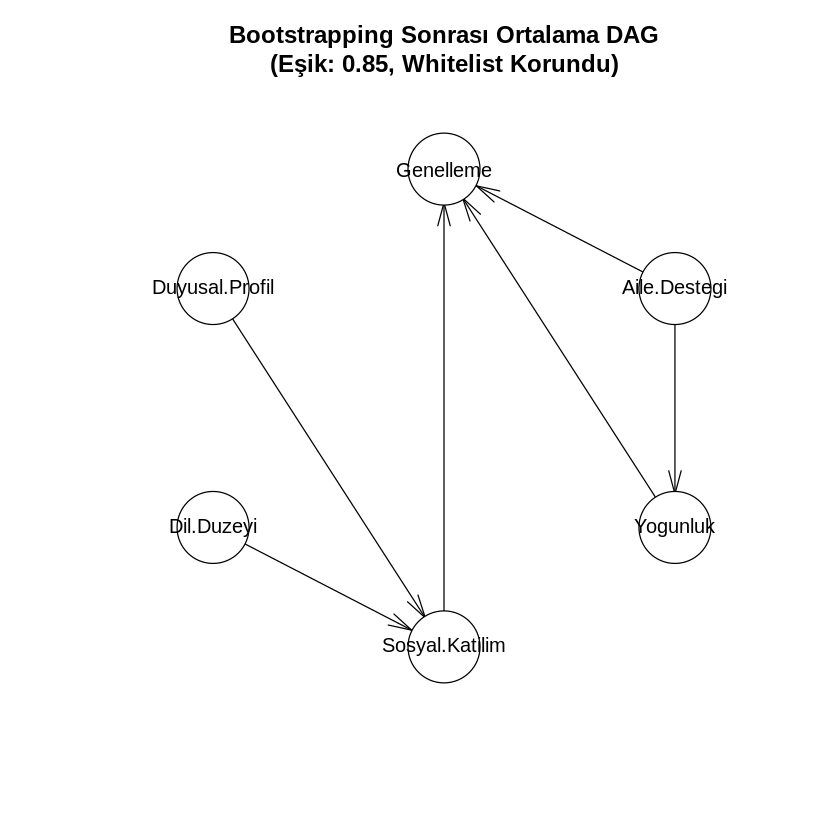

In [8]:
cat("\n--- DEĞERLENDİRME ---\n")

set.seed(42)
boot_sonuclari <- boot.strength(
  data = learning.test,
  R = 500,
  algorithm = "mmhc",
  algorithm.args = list(whitelist = wl, blacklist = bl)
)

cat("\nBootstrap Sonuçları (İlk 6 satır):\n")
print(head(boot_sonuclari))

guvenilir_kenarlar <- boot_sonuclari[boot_sonuclari$strength > 0.85 & boot_sonuclari$direction > 0.50, ]
cat("\nOldukça Güvenilir Kenarlar (Strength > 0.85):\n")
print(guvenilir_kenarlar)

sinirda_kenarlar <- boot_sonuclari[boot_sonuclari$strength > 0.50 & boot_sonuclari$strength <= 0.85, ]
cat("\nSınırdaki Kenarlar (Strength 0.50 - 0.85):\n")
print(sinirda_kenarlar)

cat("\n--- WHITELIST TUTARLILIK KONTROLÜ ---\n")
for (i in 1:nrow(wl)) {
  from_node <- wl$from[i]
  to_node   <- wl$to[i]
  satir <- boot_sonuclari[
    boot_sonuclari$from == from_node & boot_sonuclari$to == to_node,
  ]
  if (nrow(satir) > 0) {
    str_val <- satir$strength
    cat(sprintf("Whitelist kenarı %s -> %s: bootstrap strength = %.3f\n",
                from_node, to_node, str_val))
    if (str_val < 0.85) {
      cat(sprintf("  UYARI: Bu kenar whitelist'te zorunlu ama bootstrap eşiğinin (0.85) altında (%.3f)\n",
                  str_val))
      cat("  Bu kenar ortalama DAG'a zorla ekleniyor — domain knowledge kararı\n")
    } else {
      cat("  OK: Kenar bootstrap ile de tutarlı\n")
    }
  }
}

ort_dag <- averaged.network(boot_sonuclari, threshold = 0.85)

for (i in 1:nrow(wl)) {
  kenar_var <- any(
    arcs(ort_dag)[,1] == wl$from[i] & arcs(ort_dag)[,2] == wl$to[i]
  )
  if (!kenar_var) {
    ort_dag <- set.arc(ort_dag, wl$from[i], wl$to[i])
    cat(sprintf("Whitelist kenarı %s -> %s ortalama DAG'a eklendi\n", wl$from[i], wl$to[i]))
  }
}

cat("\nOrtalama DAG Kenarları (Threshold = 0.85, whitelist korundu):\n")
print(arcs(ort_dag))

plot(ort_dag, main = "Bootstrapping Sonrası Ortalama DAG\n(Eşik: 0.85, Whitelist Korundu)")

cat("\n--- ÇIKTI KAYDETME ---\n")

bic_skoru <- score(ort_dag, data = learning.test, type = "bic")
cat(sprintf("BIC Skoru: %.4f\n", bic_skoru))

write.csv(data.frame(bic = bic_skoru), "bic_skoru.csv", row.names = FALSE)
cat("bic_skoru.csv kaydedildi\n")

saveRDS(ort_dag, "ortalama_dag.rds")
cat("ortalama_dag.rds kaydedildi\n")

write.csv(boot_sonuclari, "bootstrap_sonuclari.csv", row.names = FALSE)
cat("bootstrap_sonuclari.csv kaydedildi\n")

write.csv(arcs(ort_dag), "dag_kenarlari.csv", row.names = FALSE)
cat("dag_kenarlari.csv kaydedildi\n")

png("dag_gorsel.png", width = 800, height = 600)
plot(ort_dag, main = "Ortalama DAG (Bootstrap Eşik: 0.85)")
dev.off()
cat("dag_gorsel.png kaydedildi\n")

cat("\nPipeline tamamlandı.\n")